In [194]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

In [195]:
solar_system = pd.read_csv("solar_system.csv")
print(solar_system.shape)
print(f"Head:{solar_system.head()}")
print(f"Tail: {solar_system.tail()}")
print(f"Columns: {solar_system.columns}")
print(f"Rows: {solar_system.iloc[1:,0]}")
print(solar_system.index)
# 20 rows and 11 columns, shape is (20,11)

(20, 11)
Head:                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   5243   5514   3340   3934    1326     687   
3         Gravity (m/s^2)     3.7    8.9    9.8    1.6    3.7    23.1     9.0   
4  Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

  Uranus Neptune   Pluto  
0   86.8     102  0.0130  
1  51118   49528    2376  
2   1270    1638    1850  
3    8.7    11.0     0.7  
4   21.3    23.5     1.3  
Tail:                   Attribute Mercury Venus Earth Moon  Mars  Jupiter   Saturn  \
15     Mean Temperature (C)     167   464    15  -20   -65     -110     -140   
16  Surface Pressure (bars)       0    92     1    0  0.01  Unknown  Unknown   
17          Number of Moons       0     0     1    0     2       95      274   
18         

In [196]:
Orbital_period = solar_system.iloc[10, 1:].astype(float)
Perihelion = solar_system.iloc[8, 1:].astype(float)
Aphelion = solar_system.iloc[9, 1:].astype(float)
#Perihelion is the point on an elliptical orbit (of a body m around a larger body M), where the two planets are the closest, the shortest
#     radius on the orbit between the planets that occurs twice
#Aphelion is the point on an elliptical orbit where the two bodies are farthest apart, the radius is the largest at this point
#On an orbitl path that is non circular, two quanties of radii can be found: that where the bodies are the farthest apart, and that
#     where the bodies are closest together. Each of these liens can be extended to the other side of the shape to create to perpendicular
#     lines. The half length of the longest line is the semi mjaor axis.
semi_major_axis = (Perihelion+Aphelion)/2
new_row = pd.DataFrame({'Semi major axis':[semi_major_axis]})
solar_system = pd.concat([solar_system,new_row])

In [197]:
solar_system = solar_system.drop('Semi major axis',axis=1)
print(solar_system.shape) # 21 rows and 11 columns

(21, 11)


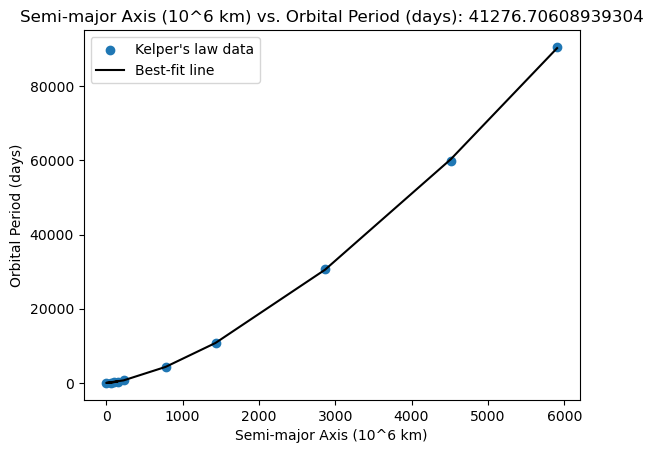

In [218]:
plt.scatter(semi_major_axis,Orbital_period, label = "Kelper's law data")

def kelpers_third_law(a,m):
    return m * a ** 1.5
popt,pcov = curve_fit(kelpers_third_law,semi_major_axis,Orbital_period)
mfit = popt
plt.plot(semi_major_axis, mfit*semi_major_axis**1.5, color = "black", label = "Best-fit line")
y_fit = mfit*semi_major_axis**1.5

residuals = Orbital_period-kelpers_third_law(semi_major_axis,mfit)
chi2 = np.sum(residuals**2)
dof = len(semi_major_axis)-len(popt)
chi2_reduced = chi2 / dof

plt.title(f"Semi-major Axis (10^6 km) vs. Orbital Period (days): {chi2_reduced}")
plt.xlabel("Semi-major Axis (10^6 km)")
plt.ylabel("Orbital Period (days)")
plt.legend()
plt.show()

In [220]:
solar_system.to_csv("kelper.csv")